In [3]:
import pandas as pd
df=pd.DataFrame({"income":[2500,1530,32150,125030,1520,5200,4120,3200,140]})
q1=df["income"].quantile(0.25)
q3=df["income"].quantile(0.75)
iqr=q3-q1
lower_bound=q1-1.5*iqr
upper_bound=q3+1.5*iqr
print(q1,q3)
print(lower_bound,upper_bound)
#cap values
df["cap"]=df["income"].clip(lower=lower_bound,upper=upper_bound)
print(df)

1530.0 5200.0
-3975.0 10705.0
   income    cap
0    2500   2500
1    1530   1530
2   32150  10705
3  125030  10705
4    1520   1520
5    5200   5200
6    4120   4120
7    3200   3200
8     140    140


In [7]:
import numpy  as np
df = pd.DataFrame({"price":[100,200,300,400,5000]})
skew=df["price"].skew()
if skew>1:
    df["price_log"]=np.log1p(df["price"])
df

,price,price_log
0,100,4.615121
1,200,5.303305
2,300,5.707110
3,400,5.993961
4,5000,8.517393


In [9]:
df = pd.DataFrame({"age":[18,25,30,40,60]})
df['age_normalized'] = (df['age'] - df['age'].min()) / (df['age'].max() - df['age'].min())
df 

,age,age_normalized
0,18,0.000000
1,25,0.166667
2,30,0.285714
3,40,0.523810
4,60,1.000000


In [10]:
df = pd.DataFrame({"salary":[3000,4000,5000,6000,7000]})
df['salary_zscore'] = (df['salary'] - df['salary'].mean()) / df['salary'].std()
df 

,salary,salary_zscore
0,3000,-1.264911
1,4000,-0.632456
2,5000,0.000000
3,6000,0.632456
4,7000,1.264911


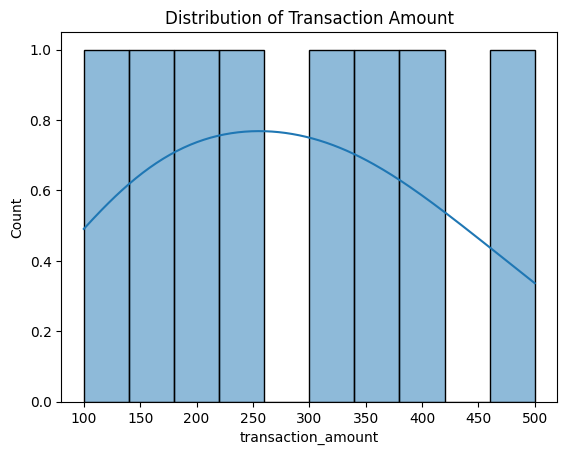

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.DataFrame({"transaction_amount":[100,200,150,300,250,400,350,500]})
sns.histplot(df['transaction_amount'], kde=True, bins=10)
plt.title("Distribution of Transaction Amount")
plt.show()


In [12]:
from sklearn.preprocessing import StandardScaler

# Sample dataset
df = pd.DataFrame({"income":[2500,3000,4000,100000,3500,2800,5000]})

# Standardize using StandardScaler
scaler = StandardScaler()
df['zscore'] = scaler.fit_transform(df[['income']])

# Remove outliers with |z| > 3
df_no_outliers = df[df['zscore'].abs() <= 3]

print("Original DataFrame:\n", df)
print("\nDataFrame without outliers:\n", df_no_outliers)


Original DataFrame:
    income    zscore
0    2500 -0.436749
1    3000 -0.421952
2    4000 -0.392356
3  100000  2.448841
4    3500 -0.407154
5    2800 -0.427871
6    5000 -0.362760

DataFrame without outliers:
    income    zscore
0    2500 -0.436749
1    3000 -0.421952
2    4000 -0.392356
3  100000  2.448841
4    3500 -0.407154
5    2800 -0.427871
6    5000 -0.362760


In [13]:
df = pd.DataFrame({"customer_spend":[100,200,300,400,500,600,700,800,900,1000]})
df['spend_bin'] = pd.cut(df['customer_spend'], bins=5, labels=False)
print(df)


   customer_spend  spend_bin
0             100          0
1             200          0
2             300          1
3             400          1
4             500          2
5             600          2
6             700          3
7             800          3
8             900          4
9            1000          4


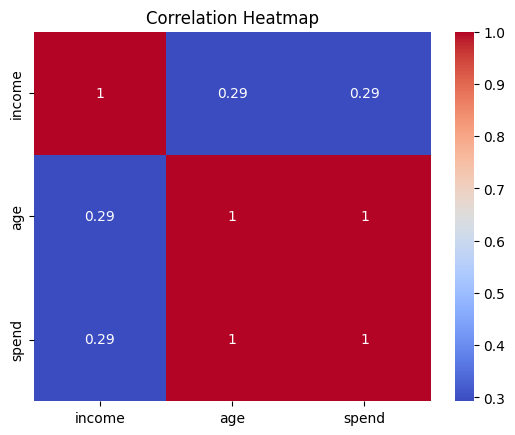

In [14]:
df = pd.DataFrame({
    "income":[2500,3000,4000,3500,2800],
    "age":[25,30,35,40,45],
    "spend":[200,250,300,350,400]
})

corr = df.corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


In [16]:
data={
    "score":[25,np.nan,35,40,45,50,15,12,26,34,15,62,45,15,26,32,62,32,51,32,62,15]
}
df=pd.DataFrame(data)
df.head()
df.isnull()
df["score"].fillna(df["score"].mean(),inplace=True)
df.head()
df.isnull().sum()

C:\Users\prasa\AppData\Local\Temp\ipykernel_152\3481764687.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["score"].fillna(df["score"].mean(),inplace=True)


score    0
dtype: int64

In [15]:
from sklearn.preprocessing import StandardScaler

df = pd.DataFrame({
    "income":[2500,3000,4000,3500,2800],
    "age":[25,30,35,40,45],
    "spend":[200,250,300,350,400]
})

scaler = StandardScaler()
scaled = scaler.fit_transform(df)
df_scaled = pd.DataFrame(scaled, columns=df.columns)
print(df_scaled)


     income       age     spend
0 -1.241971 -1.414214 -1.414214
1 -0.301084 -0.707107 -0.707107
2  1.580691  0.000000  0.000000
3  0.639803  0.707107  0.707107
4 -0.677439  1.414214  1.414214


------------------------------------------------------------

Rare cities: Index(['tadipathri', 'piduguralla', 'narasayapalem'], dtype='object', name='City')


0     2
1     2
2     2
3     3
4     2
     ..
61    5
62    4
63    3
64    3
65    3
Name: City_freq, Length: 66, dtype: int64

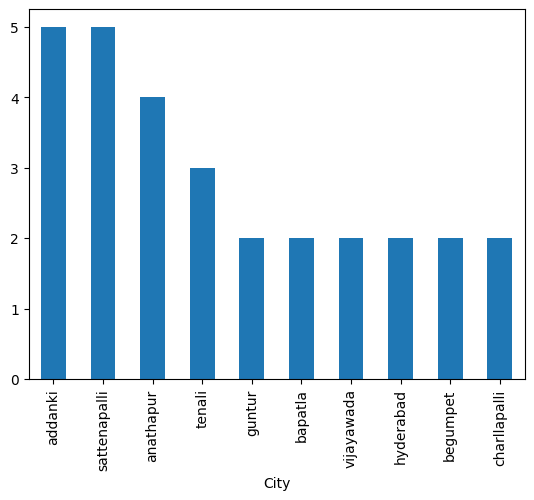

In [27]:
'''categorical variable 'City' containins 500 unique categories
During EDA how would you analyze the distribution and decide whether to group rare categories, apply encoding, or drop the variable'''
from cv2 import threshold


data={
    "City": ["bapatla", "guntur", "chirala","tenali", "ongole", "nellore", "vijayawada", "hyderabad", "begumpet", "charllapalli", "nagarsol","ammarpet","shirdi","pune","kolkata","mangalagiri","tirupathi","renigunta","chennai","bengaloru","kavali","gudivada","machilipatnam","narsaraopet","tenali","sattenapalli","addanki","chirala","bapatla","guntur","ongole","nellore","vijayawada","hyderabad","begumpet","charllapalli","nagarsol","ammarpet","shirdi","pune","kolkata","mangalagiri","tirupathi","renigunta","chennai","bengaloru","kavali","gudivada","machilipatnam","narsaraopet","tenali","sattenapalli","addanki","anathapur","sattenapalli","addanki","anathapur","sattenapalli","addanki","anathapur","sattenapalli","addanki","anathapur","tadipathri","piduguralla","narasayapalem"]}
df=pd.DataFrame(data)
city_counts = df['City'].value_counts()
city_counts.head(10).plot(kind='bar')

threshold=2
rare_cities = city_counts[city_counts < threshold].index
print("Rare cities:", rare_cities)
df['City_grouped'] = df['City'].replace(rare_cities, 'Other')
df["City_grouped"].value_counts()

df['City_freq'] = df['City_grouped'].map(df['City_grouped'].value_counts())
df["City_freq"]